In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Bagian awal hanya menyiapkan alat. NumPy dipakai untuk hitungan angka dan array, pandas untuk menampilkan hasil dalam tabel yang rapi, dan matplotlib untuk membuat grafik. Tidak ada hasil perhitungan di sini.

In [2]:
dx = 0.431
x = np.arange(17) * dx

lebar_cm = np.array([75, 83, 91, 90, 92, 92, 92, 92, 92, 92, 92, 91, 90, 86, 80, 70, 57])
tinggi_cm = np.array([81, 97, 109, 113, 113, 113, 113, 113, 113, 113, 112, 112, 112, 112, 112, 112, 112])

lebar = lebar_cm / 100
tinggi = tinggi_cm / 100

Lambung dipotong menjadi 17 titik pengukuran dengan jarak sama, 0,431 m, sehingga totalnya 6,896 m dari buritan ke haluan. Di tiap titik ada dua ukuran: lebar (dari tampak atas) dan tinggi (dari tampak samping). Ukuran aslinya dalam cm, lalu dibagi 100 supaya menjadi meter dan volume akhirnya keluar dalam m³. Kalau kamu menemukan angka yang meleset saat mencocokkan dengan gambar, cukup ubah angkanya di sini.

In [3]:
assert len(x) == len(lebar) == len(tinggi)
assert not (np.isnan(lebar).any() or np.isnan(tinggi).any())
assert np.all(np.diff(x) > 0)
assert np.allclose(np.diff(x), dx)
assert (len(x) - 1) % 2 == 0
print("Data valid:", len(x), "titik,", len(x) - 1, "interval")

Data valid: 17 titik, 16 interval


Sebelum menghitung, kode memastikan datanya layak. Jumlah titik x, lebar, dan tinggi harus sama, tidak boleh ada nilai kosong, posisi harus berurutan, dan jarak antartitik harus seragam. Jumlah interval juga harus genap karena Simpson 1/3 mensyaratkannya. Kalau salah satu gagal, program berhenti dengan error. Kalau semuanya lolos, muncul tulisan "Data valid: 17 titik, 16 interval".

In [4]:
luas = lebar * tinggi

tabel = pd.DataFrame({
    "Posisi (m)": x.round(3),
    "Lebar (m)": lebar,
    "Tinggi (m)": tinggi,
    "Luas (m²)": luas.round(4),
})
tabel

,Posisi (m),Lebar (m),Tinggi (m),Luas (m²)
0,0.000,0.75,0.81,0.6075
1,0.431,0.83,0.97,0.8051
2,0.862,0.91,1.09,0.9919
3,1.293,0.90,1.13,1.0170
4,1.724,0.92,1.13,1.0396
5,2.155,0.92,1.13,1.0396
6,2.586,0.92,1.13,1.0396
7,3.017,0.92,1.13,1.0396
8,3.448,0.92,1.13,1.0396
9,3.879,0.92,1.13,1.0396


Karena lantai datar dan tampak depan persegi panjang, luas tiap potongan cukup lebar × tinggi. Di bagian tengah lambung luasnya sekitar 1,04 m² (0,92 m × 1,13 m). Di ujung buritan sekitar 0,61 m² dan di ujung haluan sekitar 0,64 m², jadi lambung memang mengecil di kedua ujungnya. Tabelnya menampilkan posisi, lebar, tinggi, dan luas di tiap titik.

In [5]:
def trapezoid(x, y):
    total = 0
    for i in range(len(x) - 1):
        total += (x[i+1] - x[i]) * (y[i] + y[i+1]) / 2
    return total

def simpson13(x, y):
    n = len(x) - 1
    h = x[1] - x[0]
    return h / 3 * (y[0] + y[-1] + 4 * y[1:-1:2].sum() + 2 * y[2:-1:2].sum())

v_trap = trapezoid(x, luas)
v_simp = simpson13(x, luas)

print(f"Trapesium  : {v_trap:.4f} m³")
print(f"Simpson 1/3: {v_simp:.4f} m³")

Trapesium  : 6.6268 m³
Simpson 1/3: 6.6324 m³


Volume adalah luas penampang yang "ditumpuk" sepanjang lambung. Karena luasnya berubah-ubah, dipakai integrasi numerik.

Trapesium menghitung tiap potongan sebagai luas rata-rata kedua ujungnya × jarak potongan, lalu menjumlahkan semuanya. Cara ini sederhana tetapi menganggap perubahan luas lurus.
Simpson 1/3 menganggap perubahan luas melengkung, sehingga lebih akurat untuk bentuk lambung yang membulat. Titik bernomor ganjil dikali 4 dan titik genap di tengah dikali 2.

Hasilnya 6,6268 m³ (Trapesium) dan 6,6324 m³ (Simpson). Selisihnya sangat kecil, yang menandakan datanya cukup rapat dan hitungannya stabil. Simpson dijadikan metode utama.

In [6]:
A_awal, A_akhir = luas[:-1], luas[1:]
A_rata = (A_awal + A_akhir) / 2

detail = pd.DataFrame({
    "x awal (m)": x[:-1].round(3),
    "x akhir (m)": x[1:].round(3),
    "Δx (m)": np.diff(x).round(3),
    "A awal (m²)": A_awal.round(4),
    "A akhir (m²)": A_akhir.round(4),
    "A rata-rata (m²)": A_rata.round(4),
    "Volume (m³)": (A_rata * np.diff(x)).round(4),
})
detail

,x awal (m),x akhir (m),Δx (m),A awal (m²),A akhir (m²),A rata-rata (m²),Volume (m³)
0,0.000,0.431,0.431,0.6075,0.8051,0.7063,0.3044
1,0.431,0.862,0.431,0.8051,0.9919,0.8985,0.3873
2,0.862,1.293,0.431,0.9919,1.0170,1.0044,0.4329
3,1.293,1.724,0.431,1.0170,1.0396,1.0283,0.4432
4,1.724,2.155,0.431,1.0396,1.0396,1.0396,0.4481
5,2.155,2.586,0.431,1.0396,1.0396,1.0396,0.4481
6,2.586,3.017,0.431,1.0396,1.0396,1.0396,0.4481
7,3.017,3.448,0.431,1.0396,1.0396,1.0396,0.4481
8,3.448,3.879,0.431,1.0396,1.0396,1.0396,0.4481
9,3.879,4.310,0.431,1.0396,1.0304,1.0350,0.4461


Tabel ini membuka isi perhitungan Trapesium supaya tidak hanya angka akhir yang terlihat. Tiap baris adalah satu potongan lambung: dari x berapa sampai x berapa, luas di awal dan akhir, luas rata-ratanya, dan volume potongan itu. Di bagian tengah, tiap potongan bervolume sekitar 0,45 m³. Di ujung-ujungnya volumenya lebih kecil. Kalau semua volume potongan dijumlahkan, hasilnya sama dengan volume Trapesium di atas.

In [7]:
volume_lambung_1 = v_simp
volume_lambung_2 = simpson13(x, lebar * tinggi)
volume_total = volume_lambung_1 + volume_lambung_2

print(f"Volume lambung 1 : {volume_lambung_1:.4f} m³")
print(f"Volume lambung 2 : {volume_lambung_2:.4f} m³")
print(f"Total volume     : {volume_total:.4f} m³")

Volume lambung 1 : 6.6324 m³
Volume lambung 2 : 6.6324 m³
Total volume     : 13.2648 m³


Kedua lambung dianggap identik karena di tampak atas lebarnya hampir sama persis (selisih paling besar 0,4 cm di 15 titik yang dicek). Jadi volume lambung 2 dihitung dengan data yang sama dan hasilnya sama, 6,63 m³ untuk masing-masing. Total kedua lambung adalah penjumlahan keduanya, sekitar 13,26 m³.

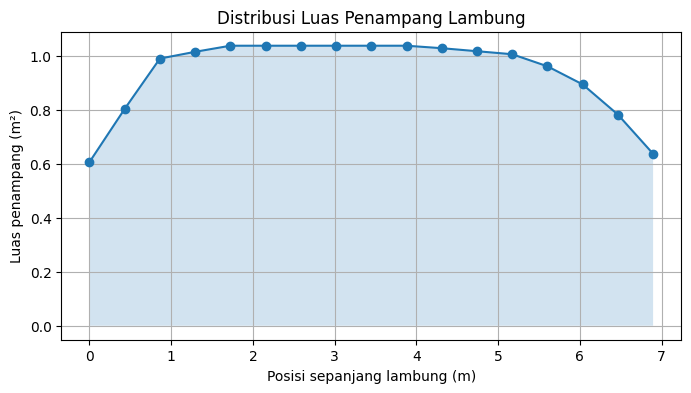

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(x, luas, "o-")
plt.fill_between(x, luas, alpha=0.2)
plt.title("Distribusi Luas Penampang Lambung")
plt.xlabel("Posisi sepanjang lambung (m)")
plt.ylabel("Luas penampang (m²)")
plt.grid(True)
plt.show()

Grafik menunjukkan bagaimana luas penampang berubah sepanjang lambung. Bentuknya seperti dataran: naik cepat di dekat buritan, datar di bagian tengah, lalu turun ke arah haluan. Area yang diarsir di bawah kurva itulah yang sebenarnya dihitung sebagai volume, jadi grafik ini membantu melihat dari mana angka 6,63 m³ berasal.

In [9]:
error = abs(v_simp - v_trap)
persen_error = error / v_simp * 100

print(f"Selisih Simpson vs Trapesium: {error:.4f} m³ ({persen_error:.3f} %)")

Selisih Simpson vs Trapesium: 0.0056 m³ (0.085 %)


Volume kedua lambung perahu katamaran dihitung dengan cara membagi lambung menjadi 16 potongan sepanjang 6,896 m (dari sekat buritan sampai sekat haluan). Pada tiap potongan, luas penampang dihitung dari lebar × tinggi karena lantai datar dan tampak depan persegi panjang. Luas-luas itu lalu dijumlahkan dengan metode Simpson 1/3, dan hasilnya dibandingkan dengan metode Trapesium (selisihnya hanya sekitar 0,09%).

**Hasilnya:**

Volume lambung 1 ≈ 6,63 m³

Volume lambung 2 ≈ 6,63 m³

Total volume ≈ 13,26 m³

Kedua lambung dianggap identik karena bentuknya sama di tampak atas. Bagian reserve buoyancy tidak dihitung sesuai instruksi, dan ukuran diperoleh dari gambar dengan skala 1 dash-kosong = 5 + 5 cm = 10 cm, sehingga hasilnya punya ketelitian sekitar ±1 cm per pembacaan.